# Block Diagram Reduction

**Learning Goals**
- Apply reduction rules (series, parallel, feedback) to simplify multi-block diagrams
- See how reduction transforms a complex diagram into a single equivalent transfer function
- Explore the closed-loop response under different gains

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

s = sp.symbols('s')

class Summer:
    def __init__(self, x, y, r=0.18, top=None, bottom=None, left=None):
        self.x = x; self.y = y; self.r = r
        self.top_sym = top; self.bottom_sym = bottom; self.left_sym = left
    @property
    def entry_left(self):   return (self.x - self.r, self.y)
    @property
    def entry_top(self):    return (self.x, self.y + self.r)
    @property
    def entry_bottom(self): return (self.x, self.y - self.r)
    @property
    def exit(self):         return (self.x + self.r, self.y)

class Block:
    def __init__(self, x, y, label, w=0.8, h=0.4, facecolor='lightblue'):
        self.x = x; self.y = y; self.label = label
        self.w = w; self.h = h; self.fc = facecolor
    @property
    def left(self):    return self.x - self.w / 2
    @property
    def right(self):   return self.x + self.w / 2
    @property
    def top(self):     return self.y + self.h / 2
    @property
    def bottom(self):  return self.y - self.h / 2
    @property
    def center_left(self):   return (self.left, self.y)
    @property
    def center_right(self):  return (self.right, self.y)
    @property
    def center_top(self):    return (self.x, self.top)
    @property
    def center_bottom(self): return (self.x, self.bottom)

def draw_block_obj(ax, block):
    xy = (block.left, block.bottom)
    box = FancyBboxPatch(xy, block.w, block.h, boxstyle='round,pad=0.05', facecolor=block.fc, edgecolor='k', lw=1.5)
    ax.add_patch(box)
    ax.text(block.x, block.y, block.label, ha='center', va='center', fontsize=11, fontweight='bold')

def draw_summing_obj(ax, s):
    c = Circle((s.x, s.y), s.r, facecolor='white', edgecolor='k', lw=1.5)
    ax.add_patch(c)
    d = s.r * 0.5
    if s.top_sym is not None:
        ax.text(s.x, s.y + d, s.top_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.bottom_sym is not None:
        ax.text(s.x, s.y - d, s.bottom_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.left_sym is not None:
        ax.text(s.x - d, s.y, s.left_sym, ha='center', va='center', fontsize=7, fontweight='bold')

def draw_connection(ax, p1, p2, label='', style='arc3,rad=0'):
    arrow = FancyArrowPatch(p1, p2, arrowstyle='->', connectionstyle=style, lw=1, color='k')
    ax.add_patch(arrow)
    if label:
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + 0.1
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, style='italic')

def connect_blocks(ax, b1, b2, label='', side1='right', side2='left'):
    p1 = getattr(b1, f'center_{side1}')
    p2 = getattr(b2, f'center_{side2}')
    draw_connection(ax, p1, p2, label)

def draw_line(ax, pts):
    xs, ys = zip(*pts)
    ax.plot(xs, ys, 'k-', lw=1.5)

def draw_dot(ax, xy):
    ax.plot(*xy, 'ko', ms=4)

def setup_axes(ax, xl, yl):
    ax.set(xlim=xl, ylim=yl, aspect='equal')
    ax.axis('off')

print("Libraries loaded.")

Libraries loaded.


---

## Block diagram reduction rules

Real systems have many interconnected blocks. **Block diagram reduction** lets us simplify any interconnection into a single equivalent block.

There are three fundamental rules (plus rules for moving summing junctions and take-off points).

### Series (cascade) rule

Blocks in series **multiply**:

$$G_{\text{eq}} = G_1 \, G_2$$

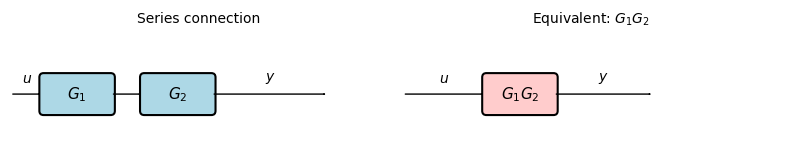

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.4))
setup_axes(ax1, (0, 4.5), (0, 1.5))
ax1.set_title('Series connection', fontsize=10)
g1 = Block(0.8, 0.75, '$G_1$')
g2 = Block(2.0, 0.75, '$G_2$')
draw_block_obj(ax1, g1)
draw_block_obj(ax1, g2)
connect_blocks(ax1, g1, g2)
draw_connection(ax1, (0, 0.75), g1.center_left, '$u$')
draw_connection(ax1, g2.center_right, (3.8, 0.75), '$y$')
setup_axes(ax2, (0, 4.5), (0, 1.5))
ax2.set_title('Equivalent: $G_1 G_2$', fontsize=10)
beq = Block(1.4, 0.75, '$G_1 G_2$', facecolor='#FFCCCC')
draw_block_obj(ax2, beq)
draw_connection(ax2, (0, 0.75), beq.center_left, '$u$')
draw_connection(ax2, beq.center_right, (3.0, 0.75), '$y$')
fig.tight_layout()
plt.show()

### Parallel rule

Blocks in parallel **add** (with sign):

$$G_{\text{eq}} = G_1 + G_2$$

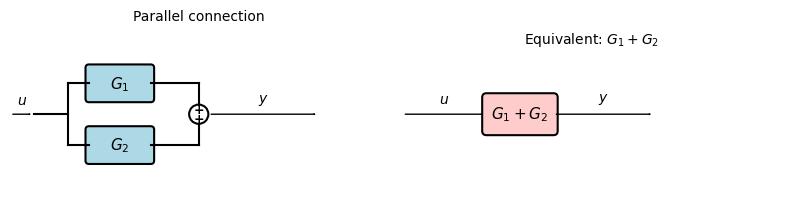

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.3))
setup_axes(ax1, (0, 5.5), (0, 2.5))
ax1.set_title('Parallel connection', fontsize=10)
s_out = Summer(2.75, 1.25, r=0.14, top='+', bottom='+')
g1 = Block(1.6, 1.7, '$G_1$', w=0.9, h=0.45)
g2 = Block(1.6, 0.8, '$G_2$', w=0.9, h=0.45)
draw_summing_obj(ax1, s_out)
draw_block_obj(ax1, g1)
draw_block_obj(ax1, g2)
draw_line(ax1, [g1.center_left, (g1.left - 0.3, g1.y)])
draw_line(ax1, [g2.center_left, (g2.left - 0.3, g2.y)])
draw_line(ax1, [(g1.left - 0.3, g1.y), (g1.left - 0.3, g2.y)])
draw_line(ax1, [(g1.left - 0.3, (g1.y + g2.y) / 2), (g1.left - 0.8, (g1.y + g2.y) / 2)])
draw_connection(ax1, (0, (g1.y + g2.y) / 2), (g1.left - 0.8, (g1.y + g2.y) / 2), '$u$')
draw_line(ax1, [g1.center_right, (s_out.entry_top[0], g1.y)])
draw_line(ax1, [g2.center_right, (s_out.entry_top[0], g2.y)])
draw_line(ax1, [(s_out.entry_top[0], g1.y), s_out.entry_top])
draw_line(ax1, [(s_out.entry_top[0], g2.y), s_out.entry_bottom])
draw_connection(ax1, s_out.exit, (4.5, s_out.y), '$y$')
setup_axes(ax2, (0, 4.5), (0, 1.5))
ax2.set_title('Equivalent: $G_1 + G_2$', fontsize=10)
beq = Block(1.4, 0.75, '$G_1 + G_2$', facecolor='#FFCCCC')
draw_block_obj(ax2, beq)
draw_connection(ax2, (0, 0.75), beq.center_left, '$u$')
draw_connection(ax2, beq.center_right, (3.0, 0.75), '$y$')
fig.tight_layout()
plt.show()

### Feedback rule

A negative-feedback loop reduces to:

$$G_{\text{CL}} = \frac{G}{1 + G H}$$

For positive feedback: $\displaystyle \frac{G}{1 - G H}$

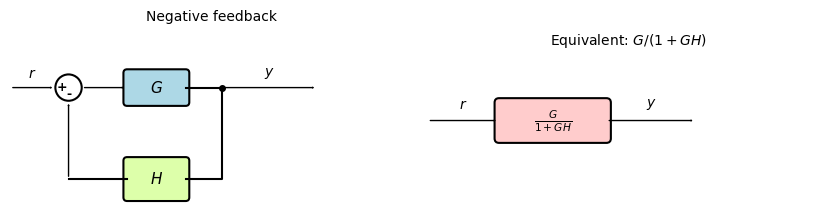

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3))
setup_axes(ax1, (0, 5.5), (0, 2.5))
ax1.set_title('Negative feedback', fontsize=10)
s = Summer(0.8, 1.7, left='+', bottom='-')
g = Block(2.0, 1.7, '$G$')
h = Block(2.0, 0.45, '$H$', w=0.8, h=0.5, facecolor='#DDFFAA')
draw_summing_obj(ax1, s)
draw_block_obj(ax1, g)
draw_block_obj(ax1, h)
draw_connection(ax1, (0, 1.7), s.entry_left, '$r$')
draw_connection(ax1, s.exit, g.center_left)
jx = g.right + 0.5
draw_line(ax1, [g.center_right, (jx, 1.7)])
draw_connection(ax1, (jx, 1.7), (4.2, 1.7), '$y$')
draw_dot(ax1, (jx, 1.7))
draw_line(ax1, [(jx, 1.7), (jx, 0.45), h.center_right])
draw_line(ax1, [h.center_left, (s.x, 0.45)])
draw_connection(ax1, (s.x, 0.45), s.entry_bottom)
setup_axes(ax2, (0, 4.5), (0, 1.5))
ax2.set_title('Equivalent: $G/(1+GH)$', fontsize=10)
beq = Block(1.4, 0.75, '$\\frac{G}{1+GH}$', w=1.2, facecolor='#FFCCCC')
draw_block_obj(ax2, beq)
draw_connection(ax2, (0, 0.75), beq.center_left, '$r$')
draw_connection(ax2, beq.center_right, (3.0, 0.75), '$y$')
fig.tight_layout()
plt.show()

---

## Interactive reduction explorer

See how series, parallel, and feedback connections simplify.

In [6]:
def label_of(expr):
    s = sp.latex(expr)
    if len(s) > 18:
        s = sp.latex(sp.simplify(expr))
    if len(s) > 18:
        return '$\\cdots$'
    return f'${s}$'

G1_str = widgets.Text(value='1/s', description='$G_1(s)$:')
G2_str = widgets.Text(value='1/(s+1)', description='$G_2(s)$:')
H_str = widgets.Text(value='1', description='$H(s)$:')
mode = widgets.Dropdown(options=['Series', 'Parallel', 'Feedback (negative)', 'Feedback (positive)'],
                        value='Series', description='Connection:')
reduction_btn = widgets.Button(description='Reduce', button_style='primary')
red_out = widgets.Output()

def on_reduce(b):
    with red_out:
        clear_output(wait=True)
        try:
            G1 = sp.sympify(G1_str.value)
            G2 = sp.sympify(G2_str.value)
            H = sp.sympify(H_str.value)
        except Exception as e:
            print(f"Parse error: {e}")
            return
        m = mode.value

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 2.2))
        fig.subplots_adjust(wspace=0.35)

        if m == 'Series':
            Geq = sp.simplify(G1 * G2)
            setup_axes(ax1, (0, 4.5), (0, 1.5))
            ax1.set_title('Original: series', fontsize=9)
            b1 = Block(0.8, 0.75, label_of(G1)); b2 = Block(2.0, 0.75, label_of(G2))
            draw_block_obj(ax1, b1); draw_block_obj(ax1, b2)
            connect_blocks(ax1, b1, b2)
            draw_connection(ax1, (0, 0.75), b1.center_left, '$u$')
            draw_connection(ax1, b2.center_right, (3.8, 0.75), '$y$')
        elif m == 'Parallel':
            Geq = sp.simplify(G1 + G2)
            setup_axes(ax1, (0, 5.2), (0, 2.2))
            ax1.set_title('Original: parallel', fontsize=9)
            so = Summer(2.5, 1.1, r=0.14, top='+', bottom='+')
            b1 = Block(1.4, 1.6, label_of(G1), w=0.9, h=0.45)
            b2 = Block(1.4, 0.7, label_of(G2), w=0.9, h=0.45)
            draw_summing_obj(ax1, so); draw_block_obj(ax1, b1); draw_block_obj(ax1, b2)
            draw_line(ax1, [b1.center_left, (b1.left - 0.3, b1.y)])
            draw_line(ax1, [b2.center_left, (b2.left - 0.3, b2.y)])
            draw_line(ax1, [(b1.left - 0.3, b1.y), (b1.left - 0.3, b2.y)])
            draw_line(ax1, [(b1.left - 0.3, (b1.y + b2.y) / 2), (b1.left - 0.8, (b1.y + b2.y) / 2)])
            draw_connection(ax1, (0, (b1.y + b2.y) / 2), (b1.left - 0.8, (b1.y + b2.y) / 2), '$u$')
            draw_line(ax1, [b1.center_right, (so.entry_top[0], b1.y)])
            draw_line(ax1, [(so.entry_top[0], b1.y), so.entry_top])
            draw_line(ax1, [b2.center_right, (so.entry_top[0], b2.y)])
            draw_line(ax1, [(so.entry_top[0], b2.y), so.entry_bottom])
            draw_connection(ax1, so.exit, (4.5, so.y), '$y$')
        elif m.startswith('Feedback'):
            sign = '+' if 'positive' in m else '-'
            Geq = sp.simplify(G1 / (1 + (1 if sign == '+' else -1) * G1 * H))
            setup_axes(ax1, (0, 5.2), (0, 2.2))
            ax1.set_title(f'Original: {sign} feedback', fontsize=9)
            s1 = Summer(0.8, 1.5, left='+', bottom=sign)
            g = Block(2.0, 1.5, label_of(G1))
            h = Block(2.0, 0.4, label_of(H), w=0.7, h=0.45, facecolor='#DDFFAA')
            draw_summing_obj(ax1, s1); draw_block_obj(ax1, g); draw_block_obj(ax1, h)
            draw_connection(ax1, (0, 1.5), s1.entry_left, '$r$')
            draw_connection(ax1, s1.exit, g.center_left)
            jx = g.right + 0.4
            draw_line(ax1, [g.center_right, (jx, 1.5)])
            draw_connection(ax1, (jx, 1.5), (4.2, 1.5), '$y$')
            draw_dot(ax1, (jx, 1.5))
            draw_line(ax1, [(jx, 1.5), (jx, 0.4), h.center_right])
            draw_line(ax1, [h.center_left, (s1.x, 0.4)])
            draw_connection(ax1, (s1.x, 0.4), s1.entry_bottom)

        setup_axes(ax2, (0, 4.5), (0, 1.5))
        ax2.set_title('Reduced', fontsize=9)
        beq = Block(1.4, 0.75, label_of(Geq), w=1.2, facecolor='#FFCCCC')
        draw_block_obj(ax2, beq)
        draw_connection(ax2, (0, 0.75), beq.center_left, '$u$')
        draw_connection(ax2, beq.center_right, (3.0, 0.75), '$y$')

        fig.tight_layout(); plt.show()
        display(sp.Eq(sp.Symbol('G_{eq}'), Geq))

reduction_btn.on_click(on_reduce)
display(widgets.VBox([G1_str, G2_str, H_str, mode, reduction_btn, red_out]))
print("Enter transfer functions and click Reduce.")

Enter transfer functions and click Reduce.


---

## Interactive closed-loop step response

Adjust a gain parameter to see the closed-loop response change in real time.

In [7]:
def closed_loop_step(K=1.0):
    s = sp.symbols('s')
    num, den = sp.fraction(sp.simplify(K / (s * (s + 2) + K)))
    num_a = np.array([float(c) for c in sp.Poly(num, s).all_coeffs()], dtype=float)
    den_a = np.array([float(c) for c in sp.Poly(den, s).all_coeffs()], dtype=float)
    from scipy.signal import step
    t, y = step((num_a, den_a))
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(t, y, 'b-', linewidth=2)
    ax.axhline(1, color='k', ls='--', alpha=0.3)
    ax.set(xlabel='Time (s)', ylabel='Output', title=f'Closed-loop step (K = {K:.2f})')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

K_slider = widgets.FloatSlider(min=0.1, max=20.0, step=0.1, value=1.0,
                                description='Gain $K$:',
                                style={'description_width': 'initial'})
cl_out = widgets.Output()

def update_cl(change):
    with cl_out:
        clear_output(wait=True)
        closed_loop_step(K_slider.value)

K_slider.observe(update_cl, 'value')
display(widgets.VBox([K_slider, cl_out]))
print("For a plant G(s)=1/(s(s+2)) with unity negative feedback, the closed-loop"
      " transfer function is G_cl = K / (s^2 + 2s + K).")
print("Move the slider to see how the step response changes with K.")

For a plant G(s)=1/(s(s+2)) with unity negative feedback, the closed-loop transfer function is G_cl = K / (s^2 + 2s + K).
Move the slider to see how the step response changes with K.


---

## Summary

- **Series:** $G_{\text{eq}} = G_1 G_2$
- **Parallel:** $G_{\text{eq}} = G_1 + G_2$
- **Feedback (negative):** $G_{\text{CL}} = G / (1 + GH)$
- Reduction lets us collapse any interconnection into a single block for analysis.
- The closed-loop gain $K$ directly affects damping and settling time.